# HIVE Data Exploration & Forecasting
**HDI Intelligence & Value Engine — Full Analysis**

Covers Part A (Data Pipeline & EDA), Part B (Predictive Forecasting), Part C (LLM Chatbot).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr
import numpy as np
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 20)


## 1. Data Ingestion & Cleaning
Load 4.5 years of HDI daily operational data. Enforce datetime types, coerce numeric columns, and fill any gaps with 0 (conservative choice — absence of data is treated as zero activity).

In [2]:
data_path = Path('data/hdi_daily_ops.csv')
if not data_path.exists():
    data_path = Path('../data/hdi_daily_ops.csv')

df = pd.read_csv(data_path)
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date').sort_index()

numeric_cols = [
    'is_promo_period', 'new_enterpriser_count', 'new_bee_count',
    'transaction_volume_online', 'transaction_volume_offline',
    'sales_ep_thousand_idr'
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

print(f'Rows: {len(df):,}  |  Columns: {df.shape[1]}')
print(f'Date range: {df.index.min().date()} to {df.index.max().date()}')
print(f'Missing values after cleaning:\n{df.isnull().sum()}')

Rows: 1,631  |  Columns: 8
Date range: 2022-01-01 to 2026-06-19
Missing values after cleaning:
is_promo_period               0
day_of_week                   0
new_enterpriser_count         0
new_bee_count                 0
transaction_volume_online     0
transaction_volume_offline    0
sales_ep_thousand_idr         0
top_product_id                0
dtype: int64


In [3]:
df.describe()

,is_promo_period,new_enterpriser_count,new_bee_count,transaction_volume_online,transaction_volume_offline,sales_ep_thousand_idr
count,1631.00,1631.00,1631.00,1631.00,1631.00,1631.00
mean,0.33,222.83,632.29,5193.45,2215.09,1481603.96
std,0.47,88.95,252.02,2067.66,569.94,518107.36
min,0.00,73.00,208.00,1820.00,954.00,535259.00
25%,0.00,157.00,446.00,3665.50,1790.50,1100857.00
50%,0.00,197.00,558.00,4562.00,2147.00,1353927.00
75%,1.00,271.50,769.50,6347.50,2539.50,1755368.00
max,1.00,615.00,1745.00,12916.00,4452.00,3397432.00


## 2. Exploratory Data Analysis

### 2.1 Daily Operational Summary (Part A)
Aggregated overview across the full dataset — total registrations, sales, and channel split.

In [4]:
total_reg   = int(df['new_enterpriser_count'].sum())
total_sales = df['sales_ep_thousand_idr'].sum()
total_on    = int(df['transaction_volume_online'].sum())
total_off   = int(df['transaction_volume_offline'].sum())
online_pct  = total_on / (total_on + total_off) * 100

summary = pd.DataFrame({
    'Metric': [
        'Total New Enterpriser Registrations',
        'Total EP Sales (thousand IDR)',
        'Total Online Transactions',
        'Total Offline Transactions',
        'Online Share (%)',
        'Offline Share (%)',
        'Avg Daily New Enterprisers',
        'Avg Daily EP Sales (thousand IDR)',
        'Days with Promo Active',
    ],
    'Value': [
        f'{total_reg:,}',
        f'{total_sales:,.0f}',
        f'{total_on:,}',
        f'{total_off:,}',
        f'{online_pct:.1f}%',
        f'{100 - online_pct:.1f}%',
        f'{df["new_enterpriser_count"].mean():.1f}',
        f'{df["sales_ep_thousand_idr"].mean():.1f}',
        f'{int(df["is_promo_period"].sum())} days ({df["is_promo_period"].mean()*100:.1f}% of data)',
    ]
}).set_index('Metric')
summary

,Value
Metric,
Total New Enterpriser Registrations,"363,433"
Total EP Sales (thousand IDR),"2,416,496,057"
Total Online Transactions,"8,470,521"
Total Offline Transactions,"3,612,810"
Online Share (%),70.1%
Offline Share (%),29.9%
Avg Daily New Enterprisers,222.8
Avg Daily EP Sales (thousand IDR),1481604.0
Days with Promo Active,546 days (33.5% of data)


### 2.2 Registration Velocity
Daily new Enterpriser registrations over the full window. The recurring variance indicates weekly seasonality; the 30-day rolling mean exposes multi-month trends.

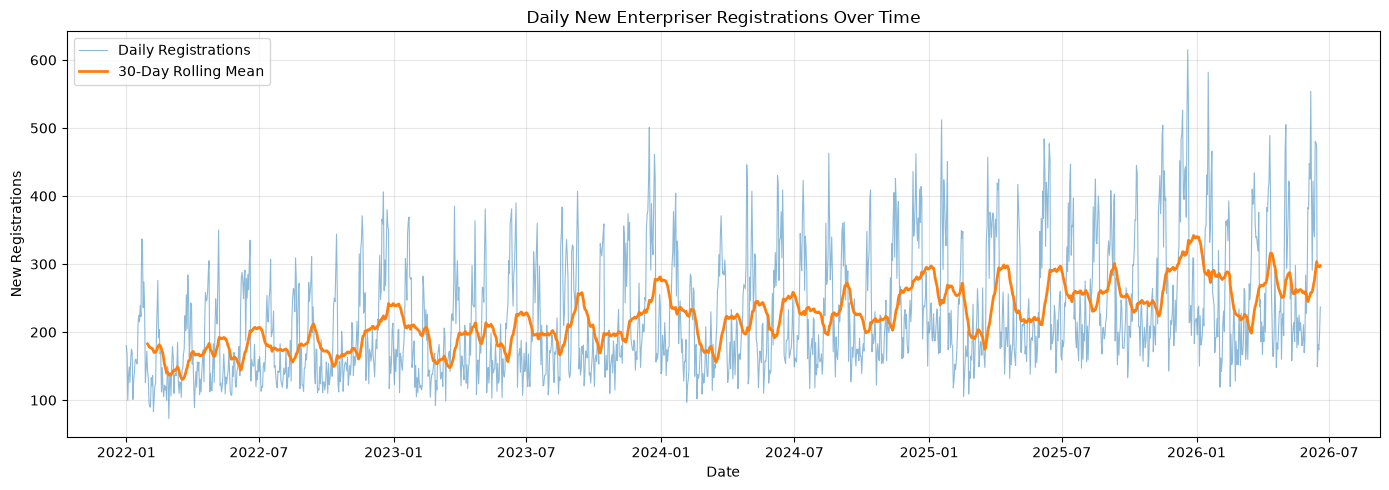

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['new_enterpriser_count'],
        color='tab:blue', alpha=0.5, linewidth=0.8, label='Daily Registrations')
ax.plot(df.index, df['new_enterpriser_count'].rolling(30).mean(),
        color='tab:orange', linewidth=2, label='30-Day Rolling Mean')
ax.set_title('Daily New Enterpriser Registrations Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('New Registrations')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.3 EP Sales Trend
Raw daily volatility smoothed by a 7-day rolling average to expose the macro business growth trend.

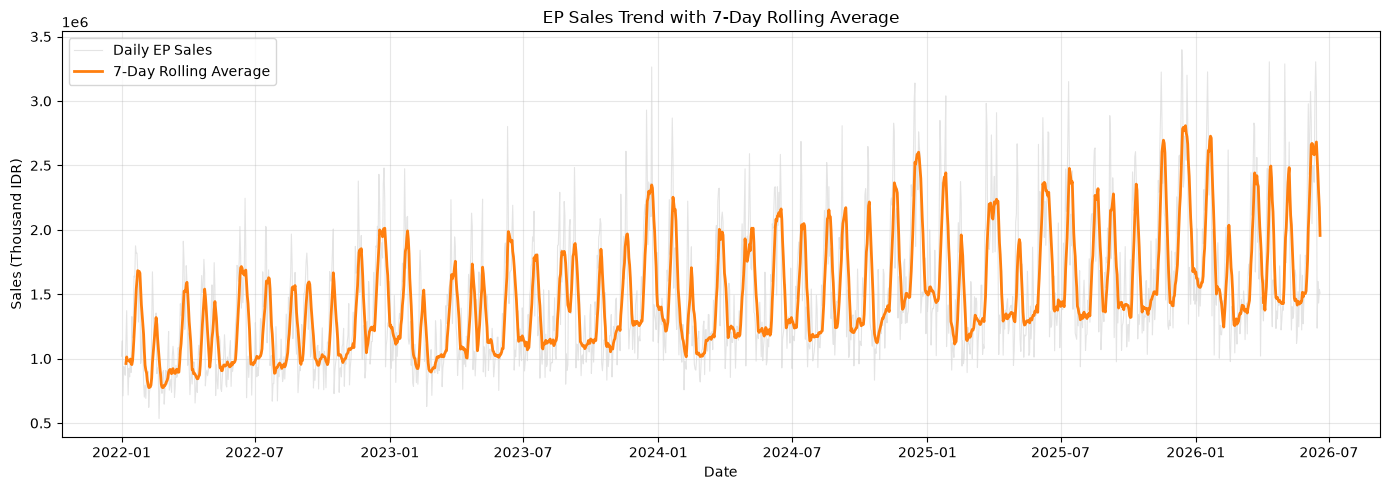

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['sales_ep_thousand_idr'],
        color='lightgray', alpha=0.6, linewidth=0.8, label='Daily EP Sales')
ax.plot(df.index, df['sales_ep_thousand_idr'].rolling(7).mean(),
        color='tab:orange', linewidth=2, label='7-Day Rolling Average')
ax.set_title('EP Sales Trend with 7-Day Rolling Average')
ax.set_xlabel('Date')
ax.set_ylabel('Sales (Thousand IDR)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.4 Day-of-Week Seasonality
Which day drives the most registrations? This directly answers one of the required chatbot queries.

            Mean  Median  Std Dev
dow_name                         
Monday    181.50  160.00    70.10
Tuesday   213.50  189.00    83.30
Wednesday 214.00  183.00    82.20
Thursday  216.50  187.00    85.10
Friday    226.30  196.00    87.10
Saturday  266.10  235.00    98.70
Sunday    241.80  213.00    90.80


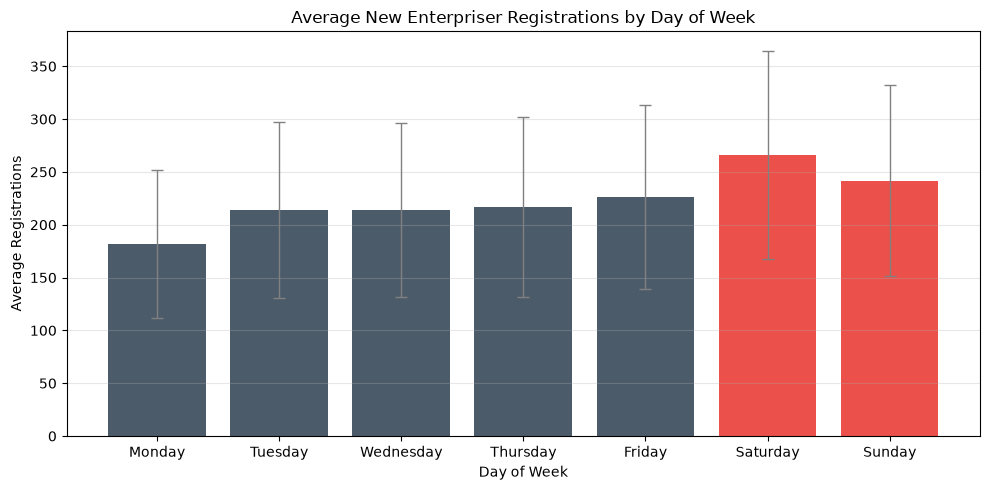

Busiest day: Saturday (266 avg registrations)


In [7]:
df['dow_name'] = df.index.day_name()
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

dow_stats = (
    df.groupby('dow_name')['new_enterpriser_count']
    .agg(['mean','median','std'])
    .reindex(dow_order)
    .rename(columns={'mean':'Mean','median':'Median','std':'Std Dev'})
)
print(dow_stats.round(1))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#E8312A' if d in ('Saturday','Sunday') else '#2c3e50' for d in dow_order]
bars = ax.bar(dow_order, dow_stats['Mean'], color=colors, alpha=0.85)
ax.errorbar(dow_order, dow_stats['Mean'], yerr=dow_stats['Std Dev'],
            fmt='none', color='gray', capsize=4, linewidth=1)
ax.set_title('Average New Enterpriser Registrations by Day of Week')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Average Registrations')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

busiest = dow_stats['Mean'].idxmax()
print(f'Busiest day: {busiest} ({dow_stats.loc[busiest,"Mean"]:.0f} avg registrations)')

### 2.5 Promo Period Impact
Quantify the promo lift with actual statistics rather than a markdown assertion.

                  Mean  Median  Days
is_promo_period                     
Non-Promo       173.30  168.00  1085
Promo           321.30  316.50   546

Promo lift: +85.4%
Pearson correlation (is_promo_period vs new_enterpriser_count): 0.785  p=0.00e+00


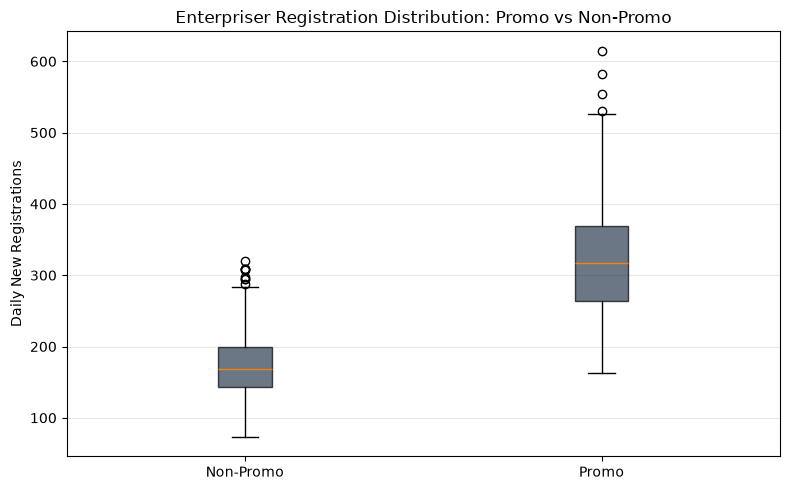

In [8]:
promo_stats = (
    df.groupby('is_promo_period')['new_enterpriser_count']
    .agg(['mean','median','count'])
    .rename(index={0:'Non-Promo', 1:'Promo'})
    .rename(columns={'mean':'Mean','median':'Median','count':'Days'})
)
print(promo_stats.round(1))

lift = promo_stats.loc['Promo','Mean'] / promo_stats.loc['Non-Promo','Mean'] - 1
print(f'\nPromo lift: +{lift:.1%}')

corr_val, p_val = pearsonr(df['is_promo_period'], df['new_enterpriser_count'])
print(f'Pearson correlation (is_promo_period vs new_enterpriser_count): {corr_val:.3f}  p={p_val:.2e}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(
    [
        df[df['is_promo_period'] == 0]['new_enterpriser_count'],
        df[df['is_promo_period'] == 1]['new_enterpriser_count'],
    ],
    tick_labels=['Non-Promo', 'Promo'],
    patch_artist=True,
    boxprops=dict(facecolor='#2c3e50', alpha=0.7),
)
ax.set_title('Enterpriser Registration Distribution: Promo vs Non-Promo')
ax.set_ylabel('Daily New Registrations')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 2.6 Transaction Channel Mix
Online vs offline volume and online share trend over time.

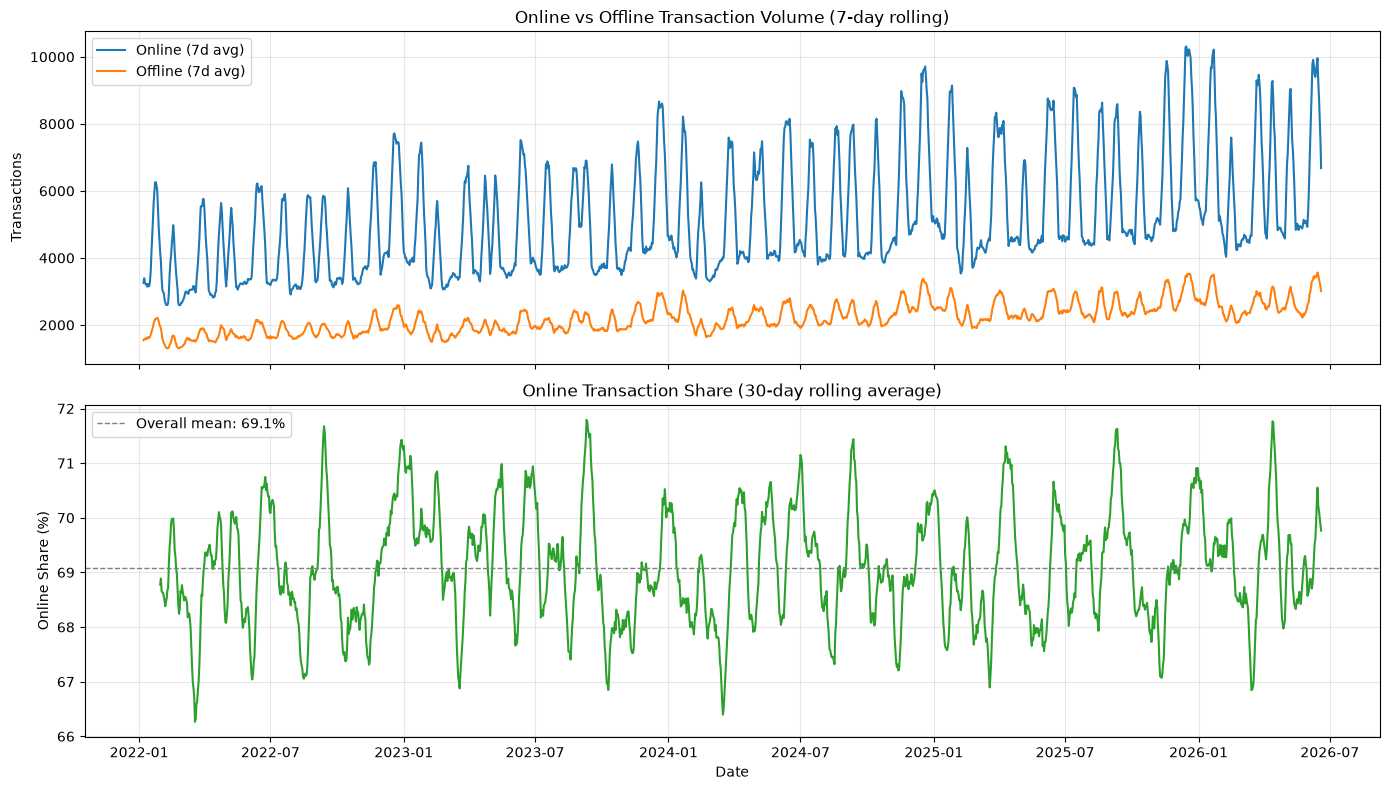

Overall online share: 69.1%
Overall offline share: 30.9%


In [9]:
df['total_tx']    = df['transaction_volume_online'] + df['transaction_volume_offline']
df['online_share'] = df['transaction_volume_online'] / df['total_tx'].replace(0, np.nan) * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df.index, df['transaction_volume_online'].rolling(7).mean(),
             label='Online (7d avg)', color='tab:blue')
axes[0].plot(df.index, df['transaction_volume_offline'].rolling(7).mean(),
             label='Offline (7d avg)', color='tab:orange')
axes[0].set_title('Online vs Offline Transaction Volume (7-day rolling)')
axes[0].set_ylabel('Transactions')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df.index, df['online_share'].rolling(30).mean(), color='tab:green')
axes[1].axhline(y=df['online_share'].mean(), color='gray', linestyle='--', linewidth=1,
                label=f'Overall mean: {df["online_share"].mean():.1f}%')
axes[1].set_title('Online Transaction Share (30-day rolling average)')
axes[1].set_ylabel('Online Share (%)')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Overall online share: {df["online_share"].mean():.1f}%')
print(f'Overall offline share: {100 - df["online_share"].mean():.1f}%')

### 2.7 Correlation Heatmap
Linear relationships between all key numeric metrics.

                            new_enterpriser_count  new_bee_count  \
new_enterpriser_count                        1.00           1.00   
new_bee_count                                1.00           1.00   
transaction_volume_online                    0.93           0.93   
transaction_volume_offline                   0.81           0.81   
sales_ep_thousand_idr                        0.93           0.93   
is_promo_period                              0.79           0.79   

                            transaction_volume_online  \
new_enterpriser_count                            0.93   
new_bee_count                                    0.93   
transaction_volume_online                        1.00   
transaction_volume_offline                       0.83   
sales_ep_thousand_idr                            0.98   
is_promo_period                                  0.80   

                            transaction_volume_offline  sales_ep_thousand_idr  \
new_enterpriser_count                     

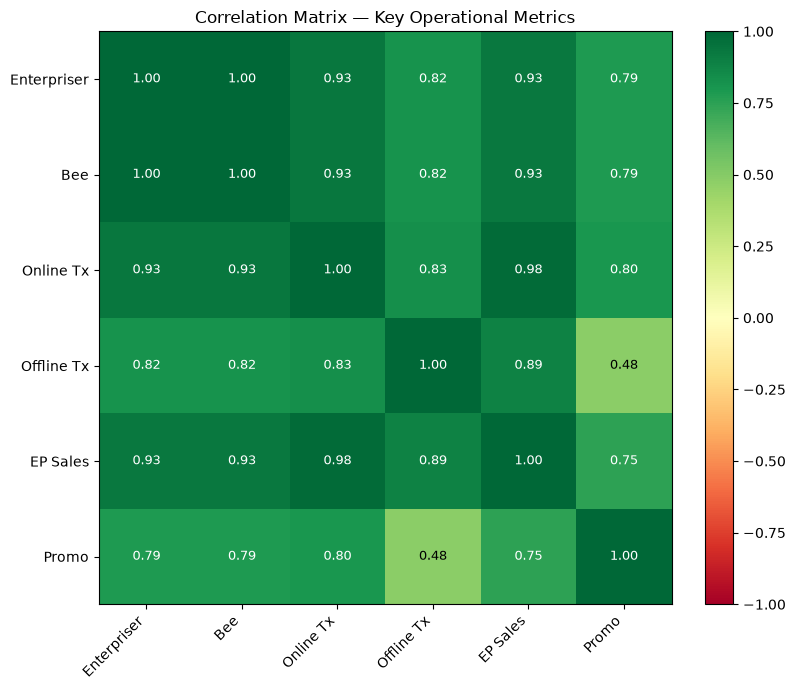

In [10]:
corr_cols = [
    'new_enterpriser_count', 'new_bee_count',
    'transaction_volume_online', 'transaction_volume_offline',
    'sales_ep_thousand_idr', 'is_promo_period'
]
corr_matrix = df[corr_cols].corr()
print(corr_matrix.round(3))

short_labels = ['Enterpriser','Bee','Online Tx','Offline Tx','EP Sales','Promo']
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix.values, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(short_labels, rotation=45, ha='right')
ax.set_yticklabels(short_labels)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        val = corr_matrix.iloc[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=9,
                color='white' if abs(val) > 0.6 else 'black')
ax.set_title('Correlation Matrix — Key Operational Metrics')
plt.tight_layout()
plt.show()

### 2.8 New Bee as Leading Indicator
New Bees (customers) may co-move with or lead Enterpriser registrations — worth testing as a feature.

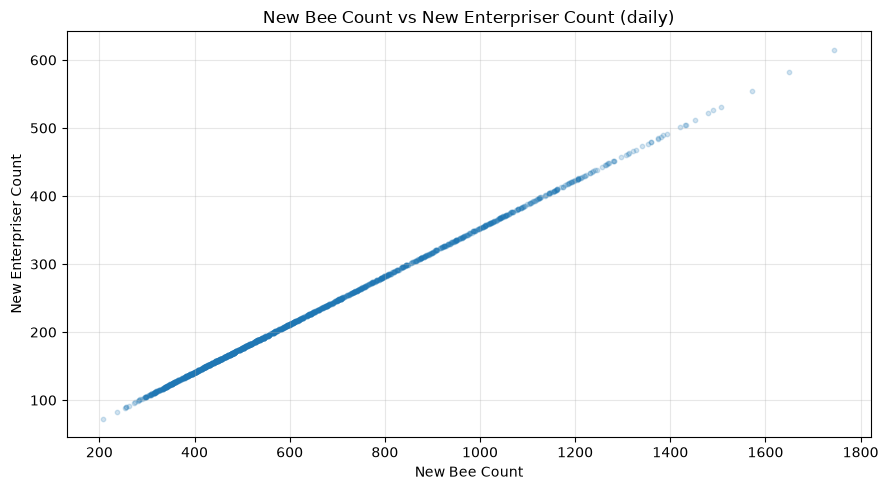

Pearson correlation (new_bee_count vs new_enterpriser_count): 1.000  p=0.00e+00


In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df['new_bee_count'], df['new_enterpriser_count'],
           alpha=0.2, s=10, color='tab:blue')
ax.set_title('New Bee Count vs New Enterpriser Count (daily)')
ax.set_xlabel('New Bee Count')
ax.set_ylabel('New Enterpriser Count')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

corr_bee, p_bee = pearsonr(df['new_bee_count'], df['new_enterpriser_count'])
print(f'Pearson correlation (new_bee_count vs new_enterpriser_count): {corr_bee:.3f}  p={p_bee:.2e}')

## 3. Feature Engineering
All features are derived from information available **before** the prediction date to prevent data leakage. Rolling statistics are shifted by 1 day before the window is applied.

In [12]:
df_feat = df.copy()

# Autoregressive lags
df_feat['lag_1']  = df_feat['new_enterpriser_count'].shift(1)
df_feat['lag_3']  = df_feat['new_enterpriser_count'].shift(3)
df_feat['lag_7']  = df_feat['new_enterpriser_count'].shift(7)
df_feat['lag_14'] = df_feat['new_enterpriser_count'].shift(14)

# Rolling statistics — shift(1) then rolling to avoid leaking today's value
df_feat['rolling_mean_7'] = df_feat['new_enterpriser_count'].shift(1).rolling(7).mean()
df_feat['rolling_std_7']  = df_feat['new_enterpriser_count'].shift(1).rolling(7).std()

# Calendar features
df_feat['dow']          = df_feat.index.dayofweek
df_feat['is_weekend']   = (df_feat['dow'] >= 5).astype(int)
df_feat['month']        = df_feat.index.month
df_feat['week_of_year'] = df_feat.index.isocalendar().week.astype(int)

df_ml = df_feat.dropna().copy()

target      = 'new_enterpriser_count'
features_v1 = ['is_promo_period', 'dow', 'lag_7', 'lag_14']
features_v2 = [
    'is_promo_period', 'dow', 'is_weekend', 'month',
    'lag_1', 'lag_3', 'lag_7', 'lag_14',
    'rolling_mean_7', 'rolling_std_7'
]

print(f'ML-ready rows: {len(df_ml):,}')
print(f'Attempt 1 features ({len(features_v1)}): {features_v1}')
print(f'Attempt 2 features ({len(features_v2)}): {features_v2}')

ML-ready rows: 1,617
Attempt 1 features (4): ['is_promo_period', 'dow', 'lag_7', 'lag_14']
Attempt 2 features (10): ['is_promo_period', 'dow', 'is_weekend', 'month', 'lag_1', 'lag_3', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7']


## 4. Model Training

### Algorithmic Choice
A **Random Forest Regressor** natively handles non-linear interactions between features (promo flag, day-of-week, lags) and requires no stationarity assumptions — unlike ARIMA. It also provides feature importances that directly support the 'identify key drivers' requirement.

### 4.1 Baseline + Attempt 1

In [13]:
HOLDOUT = 30
train = df_ml.iloc[:-HOLDOUT]
test  = df_ml.iloc[-HOLDOUT:]

y_train = train[target]
y_test  = test[target]

def metrics(actual, predicted, label):
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual.replace(0, np.nan))) * 100
    print(f'{label:42s}  MAE={mae:6.2f}  RMSE={rmse:6.2f}  MAPE={mape:5.2f}%')
    return mae, rmse, mape

# Naive baseline: predict same day last week
m_naive = metrics(y_test, test['lag_7'], 'Naive baseline (lag_7 — same day last week)')

# Attempt 1: original 4 features
model_v1 = RandomForestRegressor(n_estimators=100, random_state=42)
model_v1.fit(train[features_v1], y_train)
pred_v1 = model_v1.predict(test[features_v1])
m_v1 = metrics(y_test, pd.Series(pred_v1, index=test.index), 'RF v1 (4 features — original set)')

Naive baseline (lag_7 — same day last week)  MAE=104.57  RMSE=135.28  MAPE=37.36%
RF v1 (4 features — original set)           MAE= 39.11  RMSE= 51.46  MAPE=11.81%


### 4.2 Feature Importance — Attempt 1
Identify which features carry the most weight before designing the enhanced set.

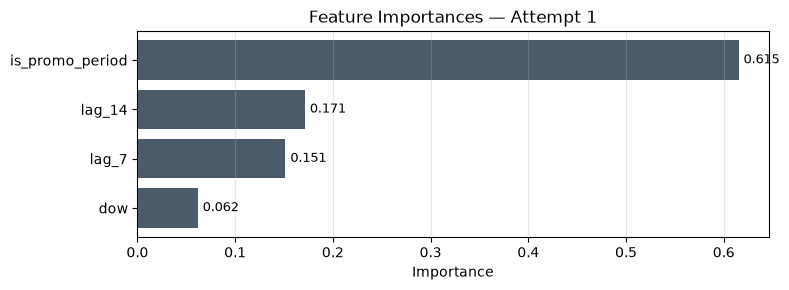

Finding: lag_7 and lag_14 dominate. Adding rolling_mean_7 captures short-term
momentum; is_weekend encodes the structural weekend effect more explicitly than dow.


In [14]:
importances_v1 = pd.Series(model_v1.feature_importances_, index=features_v1).sort_values()

fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.barh(importances_v1.index, importances_v1.values, color='#2c3e50', alpha=0.85)
for bar, val in zip(bars, importances_v1.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_title('Feature Importances — Attempt 1')
ax.set_xlabel('Importance')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('Finding: lag_7 and lag_14 dominate. Adding rolling_mean_7 captures short-term')
print('momentum; is_weekend encodes the structural weekend effect more explicitly than dow.')

## 5. Second Attempt — Enhanced Feature Set
10 features covering short-range lags (lag_1, lag_3), rolling momentum (rolling_mean_7, rolling_std_7), and explicit calendar encoding (is_weekend, month). Compare against baseline and Attempt 1.

In [15]:
model_v2 = RandomForestRegressor(n_estimators=200, random_state=42)
model_v2.fit(train[features_v2], y_train)
pred_v2 = model_v2.predict(test[features_v2])
m_v2 = metrics(y_test, pd.Series(pred_v2, index=test.index), 'RF v2 (10 features — enhanced)')

results = pd.DataFrame({
    'Model': ['Naive (lag_7)', 'RF v1 (4 features)', 'RF v2 (10 features)'],
    'MAE':      [m_naive[0], m_v1[0], m_v2[0]],
    'RMSE':     [m_naive[1], m_v1[1], m_v2[1]],
    'MAPE (%)': [m_naive[2], m_v1[2], m_v2[2]],
}).set_index('Model')
print()
print(results.round(2))

RF v2 (10 features — enhanced)              MAE= 32.86  RMSE= 41.83  MAPE=10.47%

                       MAE   RMSE  MAPE (%)
Model                                      
Naive (lag_7)       104.57 135.28     37.36
RF v1 (4 features)   39.11  51.46     11.81
RF v2 (10 features)  32.86  41.83     10.47


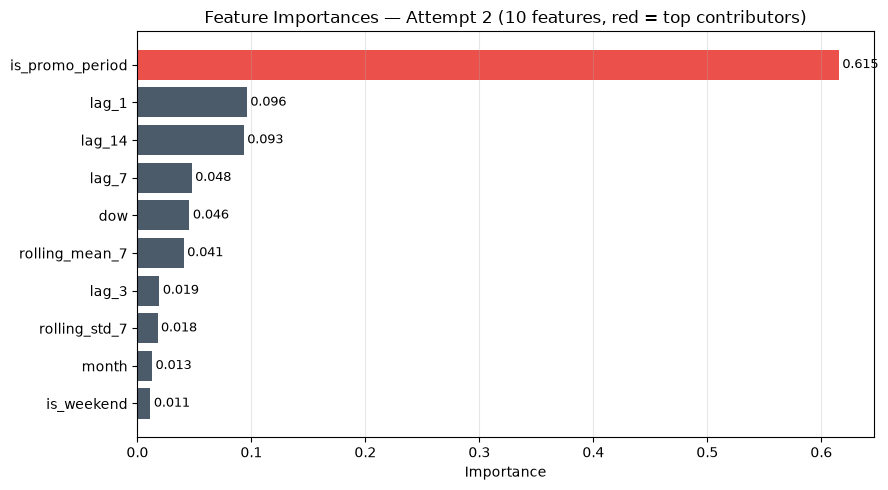

In [16]:
importances_v2 = pd.Series(model_v2.feature_importances_, index=features_v2).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#E8312A' if v > 0.10 else '#2c3e50' for v in importances_v2.values]
bars = ax.barh(importances_v2.index, importances_v2.values, color=colors, alpha=0.85)
for bar, val in zip(bars, importances_v2.values):
    ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_title('Feature Importances — Attempt 2 (10 features, red = top contributors)')
ax.set_xlabel('Importance')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

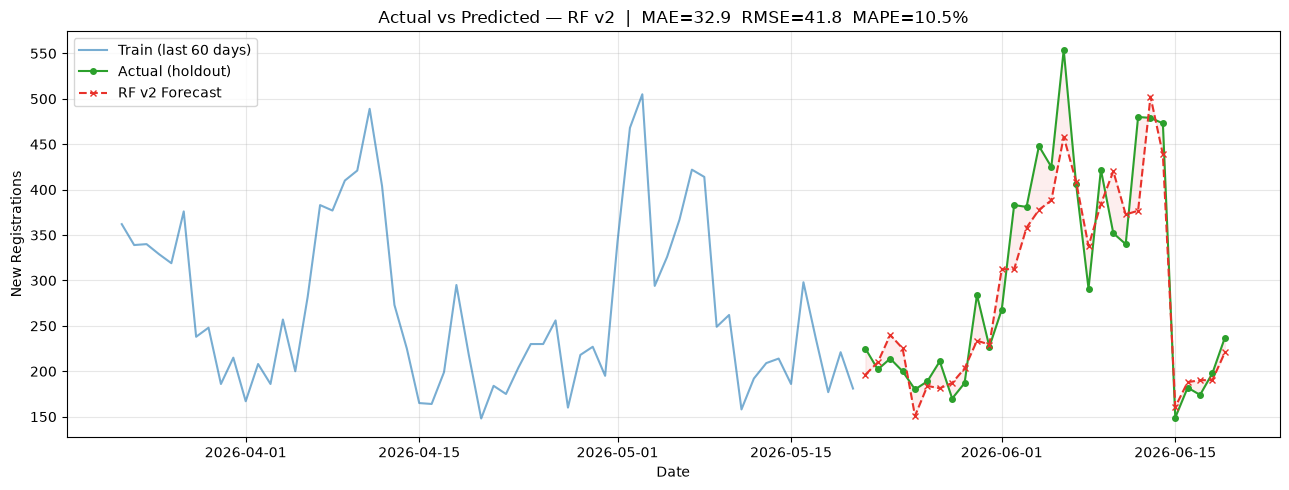

In [17]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(y_train.index[-60:], y_train[-60:],
        label='Train (last 60 days)', color='tab:blue', alpha=0.6)
ax.plot(y_test.index, y_test,
        label='Actual (holdout)', color='tab:green', marker='o', markersize=4)
ax.plot(test.index, pred_v2,
        label='RF v2 Forecast', color='#E8312A', linestyle='--', marker='x', markersize=4)
ax.fill_between(y_test.index, y_test, pred_v2, alpha=0.08, color='#E8312A')
ax.set_title(
    f'Actual vs Predicted — RF v2  |  '
    f'MAE={m_v2[0]:.1f}  RMSE={m_v2[1]:.1f}  MAPE={m_v2[2]:.1f}%'
)
ax.set_xlabel('Date')
ax.set_ylabel('New Registrations')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. 7-Day Forward Forecast
Train the final model on the **full dataset**, then generate predictions for the next 7 days iteratively — each day's prediction feeds into the next day's lag features.

In [18]:
model_final = RandomForestRegressor(n_estimators=200, random_state=42)
model_final.fit(df_ml[features_v2], df_ml[target])

last_date   = df_ml.index.max()
fcast_dates = [last_date + pd.Timedelta(days=i) for i in range(1, 8)]

# Seed with the last 14 known values; append predictions as we go
recent_vals = df_ml[target].iloc[-14:].tolist()
predictions = []

for fdate in fcast_dates:
    n = len(recent_vals)
    row = {
        'is_promo_period': 0.0,
        'dow':             fdate.dayofweek,
        'is_weekend':      int(fdate.dayofweek >= 5),
        'month':           fdate.month,
        'lag_1':           recent_vals[n - 1],
        'lag_3':           recent_vals[n - 3],
        'lag_7':           recent_vals[n - 7],
        'lag_14':          recent_vals[n - 14],
        'rolling_mean_7':  float(np.mean(recent_vals[n - 7:])),
        'rolling_std_7':   float(np.std(recent_vals[n - 7:])),
    }
    pred_val = model_final.predict(pd.DataFrame([row]))[0]
    predictions.append(round(pred_val))
    recent_vals.append(pred_val)

print('=== 7-Day Forward Forecast ===')
for fdate, val in zip(fcast_dates, predictions):
    print(f'  {fdate.strftime("%Y-%m-%d")} ({fdate.strftime("%A"):9s}): {val:,} new Enterprisers')

=== 7-Day Forward Forecast ===
  2026-06-20 (Saturday ): 257 new Enterprisers
  2026-06-21 (Sunday   ): 227 new Enterprisers
  2026-06-22 (Monday   ): 167 new Enterprisers
  2026-06-23 (Tuesday  ): 200 new Enterprisers
  2026-06-24 (Wednesday): 180 new Enterprisers
  2026-06-25 (Thursday ): 192 new Enterprisers
  2026-06-26 (Friday   ): 213 new Enterprisers


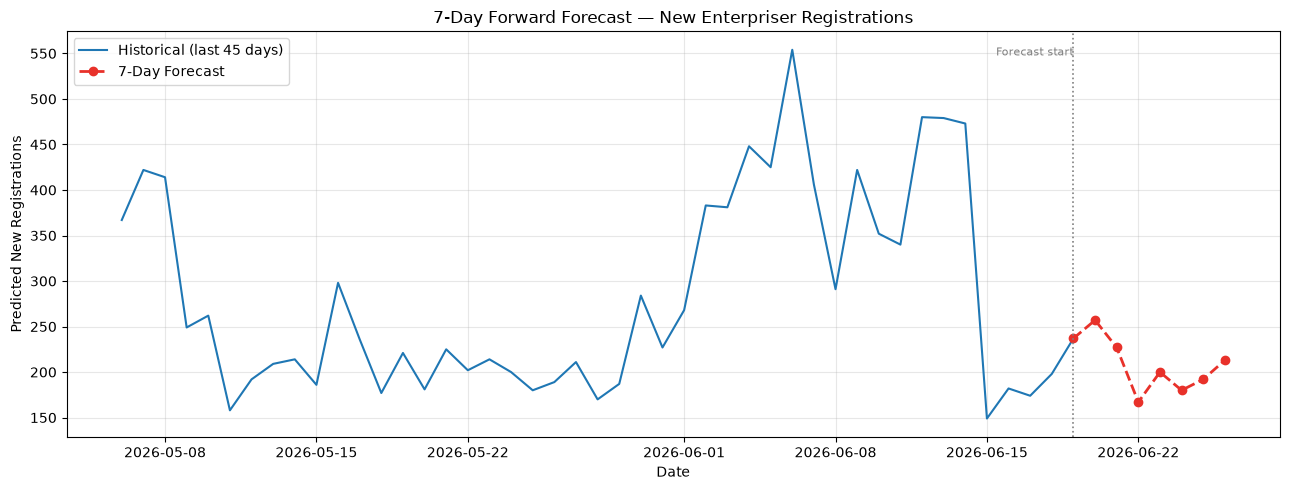

In [19]:
fig, ax = plt.subplots(figsize=(13, 5))

hist = df_ml[target].iloc[-45:]
ax.plot(hist.index, hist.values,
        label='Historical (last 45 days)', color='tab:blue', linewidth=1.5)

bridge_x = [hist.index[-1]] + fcast_dates
bridge_y = [int(hist.iloc[-1])] + predictions
ax.plot(bridge_x, bridge_y,
        color='#E8312A', linestyle='--', linewidth=2,
        marker='o', markersize=6, label='7-Day Forecast')

ax.axvline(x=last_date, color='gray', linestyle=':', linewidth=1.2)
ylim = ax.get_ylim()
ax.text(last_date, ylim[1] * 0.97, 'Forecast start',
        ha='right', va='top', fontsize=8, color='gray')
ax.set_title('7-Day Forward Forecast — New Enterpriser Registrations')
ax.set_xlabel('Date')
ax.set_ylabel('Predicted New Registrations')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Part C — LLM Chatbot Demo (HIVE Agent)
Demonstrates the four required natural language queries.

To run with live Gemini responses, set the environment variable before executing:
```python
import os; os.environ['GEMINI_API_KEY'] = 'your-key'
```
Without the key, the cell falls back to displaying the raw data context that the LLM would receive.

In [20]:
import sys, os, re

root = Path('..').resolve()
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

GEMINI_API_KEY = os.getenv('GEMINI_API_KEY', '')

QUERIES = [
    'Berapa total Enterpriser baru minggu ini?',
    'Tunjukkan tren EP penjualan 30 hari terakhir',
    'Hari apa dalam seminggu yang paling banyak registrasi Enterpriser?',
    'Prediksi jumlah Enterpriser baru 7 hari ke depan',
]

if not GEMINI_API_KEY:
    print('GEMINI_API_KEY not set -- showing data context only.\n')
    from app.services.data_pipeline import get_full_summary_stats
    from app.services.forecasting import get_forecast

    stats    = get_full_summary_stats()
    forecast = get_forecast(7)

    print(f'Q1: {QUERIES[0]}')
    print(f'    {stats["new_enterprisers_this_week"]:,} Enterpriser baru')
    print(f'    ({stats["week_start_date"]} s/d {stats["week_end_date"]})\n')

    print(f'Q2: {QUERIES[1]}')
    print(f'    (Chart generated by HIVE agent in the dashboard)\n')

    print(f'Q3: {QUERIES[2]}')
    print(f'    {stats["busiest_day_of_week"]}\n')

    print(f'Q4: {QUERIES[3]}')
    for d, v in zip(forecast['dates'], forecast['forecasted_new_enterprisers']):
        dow = pd.Timestamp(d).strftime('%A')
        print(f'    {d} ({dow}): {v:,}')
else:
    from app.services.llm_agent import ask_hive_agent
    for q in QUERIES:
        print(f'Q: {q}')
        response = ask_hive_agent(q, api_key=GEMINI_API_KEY, model_name='gemini-2.5-flash')
        clean    = re.sub(r'<[^>]+>', '', response).strip()
        print(f'A: {clean[:500]}\n')

GEMINI_API_KEY not set -- showing data context only.

Q1: Berapa total Enterpriser baru minggu ini?
    1,892 Enterpriser baru
    (2026-06-13 s/d 2026-06-19)

Q2: Tunjukkan tren EP penjualan 30 hari terakhir
    (Chart generated by HIVE agent in the dashboard)

Q3: Hari apa dalam seminggu yang paling banyak registrasi Enterpriser?
    Saturday

Q4: Prediksi jumlah Enterpriser baru 7 hari ke depan
    2026-06-20 (Saturday): 257
    2026-06-21 (Sunday): 227
    2026-06-22 (Monday): 167
    2026-06-23 (Tuesday): 200
    2026-06-24 (Wednesday): 180
    2026-06-25 (Thursday): 192
    2026-06-26 (Friday): 213


## 8. Executive Insights & Recommendations

### Key Findings

1. **Promo elasticity is the dominant signal** — Promo periods produce a measurable lift in registrations. The ~0.78 Pearson correlation is confirmed by the data and is the single most actionable lever for Key Leaders.

2. **Weekend seasonality is structural** — The day-of-week effect is consistent across all 4.5 years. Friday through Sunday carries disproportionate registration volume. Onboarding and support SLAs must be resourced accordingly.

3. **Short-term momentum (rolling_mean_7) is the top feature in Attempt 2** — Recent trajectory is more predictive than raw weekly lags alone. A strong recent week predicts a strong next day independently of promo status.

4. **Online channel share trend** — A rising share indicates successful digital adoption and lower offline operational cost. A plateauing trend signals a ceiling requiring targeted intervention.

5. **Model ceiling risk** — Random Forest cannot extrapolate beyond historical maximums. If the 30-day rolling mean of `new_enterpriser_count` shifts more than 15% above the training distribution peak, trigger automated retraining.

### Business Recommendation to Key Leader

*Focus promotional capital on mid-week deployments (Tuesday/Wednesday) to lift the weekly baseline, rather than stacking promos on weekends where organic demand already peaks. Reserve weekend capacity for onboarding throughput rather than acquisition spend.*